# Utilizar otro dataset y poner en práctica la generación de secuencias con la estategias presentadas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import nltk
import keras
from keras.src.legacy.preprocessing.text import text_to_word_sequence, Tokenizer
from keras.api.preprocessing.sequence import pad_sequences
# from tensorflow.keras.preprocessing.text import text_to_word_sequence
# from tensorflow.python.keras.preprocessing.text import Tokenizer
# from keras_preprocessing.sequence import pad_sequences # se utilizará para padding

from keras.api.models import Sequential
from keras.api.layers import Dense, LSTM, Embedding, Dropout
from keras.api.losses import SparseCategoricalCrossentropy

2024-12-17 20:02:53.357359: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-17 20:02:53.365118: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-17 20:02:53.415750: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-17 20:02:53.460997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734476573.525060   32915 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734476573.53

In [2]:
# nltk.set_proxy('http://127.0.0.1:3128')
nltk.download('mte_teip5')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package mte_teip5 to
[nltk_data]     /home/20316817603/nltk_data...
[nltk_data]   Package mte_teip5 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/20316817603/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/20316817603/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
orwell_sents = nltk.corpus.multext_east.sents('oana-en.xml')
str(orwell_sents[0])

"['It', 'was', 'a', 'bright', 'cold', 'day', 'in', 'April', ',', 'and', 'the', 'clocks', 'were', 'striking', 'thirteen', '.']"

In [5]:
nltk.word_tokenize(' '.join(orwell_sents[0]))

['It',
 'was',
 'a',
 'bright',
 'cold',
 'day',
 'in',
 'April',
 ',',
 'and',
 'the',
 'clocks',
 'were',
 'striking',
 'thirteen',
 '.']

In [6]:
# Se tuvo la intención de usar word_tokenizer de ntlk, sin embargo, esta función no elimina las puntuaciónes ni convierte el texto en minúscula. Por lo tanto se decidió utilizar text_to_word_sequence de keras
segmented_sentences = [text_to_word_sequence(' '.join(orwell_sent)) for orwell_sent in orwell_sents]
print(segmented_sentences[0])

['it', 'was', 'a', 'bright', 'cold', 'day', 'in', 'april', 'and', 'the', 'clocks', 'were', 'striking', 'thirteen']


In [7]:
length_sentences = [len(sentence) for sentence in segmented_sentences]

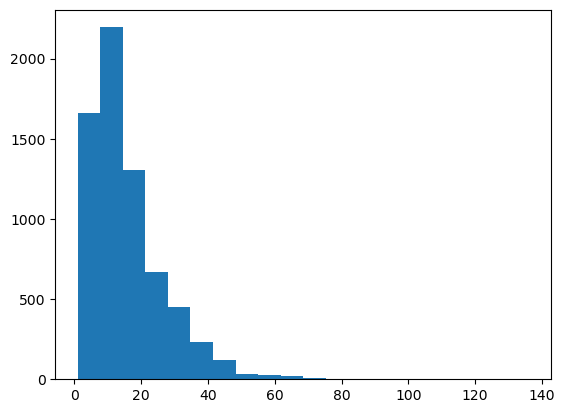

In [8]:
# podemos ver su distribución
plt.hist(length_sentences,bins=20)
plt.show()

In [9]:
# a partir de la distribución de longitudes de secuencias elegimos algún criterio
# para determinar el máximo tamaño de contexto. En este caso es un percentil, pero
# otros criterios también pueden ser válidos con la justificación adecuada.

# el -1 es porque el último token será el target
max_context_size = int(np.percentile(length_sentences, 85)-1)
# max_context_size = int(np.ceil(np.mean(length_sentences))) # criterio de media
# max_context_size = int(np.ceil(np.median(length_sentences))) # criterio de mediana
print(f'max_context_size: {max_context_size}')

max_context_size: 25


###  Tokenizar

In [10]:
# instanciamos el tokenizador
tok = Tokenizer()

# El tokenizer "aprende" las palabras que se usaran
# Se construye (fit) una vez por proyecto, se aplica N veces (tal cual un encoder)
# El token 0 es reservado y no es asignado. Se utiliza para designar a palabras
# fuera del vocabulario aprendido
tok.fit_on_texts(segmented_sentences)

# Convertimos las palabras a números
# entran palabras -> salen números
tokenized_sentences = tok.texts_to_sequences(segmented_sentences)

In [11]:
tokenized_sentences[0]

[8, 6, 3, 1426, 510, 141, 9, 1839, 4, 1, 3434, 22, 3435, 4903]

In [12]:
tokenized_sentences_train, tokenized_sentences_val, _, _ = train_test_split(tokenized_sentences, tokenized_sentences, test_size=0.2, random_state=42)


In [13]:
len(tokenized_sentences_train)

5389

In [14]:
tok_sent = []

for sent in tokenized_sentences_train:

  # si la secuencia tiene más términos que el tamaño de contexto máximo,
  # armo varias sub-secuencias de tamaño máximo
  if len(sent) > (max_context_size+1):
    extra = len(sent)-(max_context_size+1) + 1
    for i in range(extra):
      tok_sent.append(sent[i:i+max_context_size+1])
  else: # si la secuencia tiene menos términos el tamaño de contexto máximo, dejo la secuencia como está
    tok_sent.append(sent)

In [15]:
len(tok_sent)

14115

In [16]:
tok_sent_augm = []

for sent in tok_sent:

  # generamos todas las sub-secuencias
  subseq = [sent[:i+2] for i in range(len(sent)-1)]
  # en esta línea paddeamos al tamaño de contexto máximo
  tok_sent_augm.append(pad_sequences(subseq, maxlen=max_context_size+1, padding='pre'))

In [17]:
len(tok_sent_augm)

14115

In [18]:
train_seqs = np.concatenate(tok_sent_augm, axis=0)

In [19]:
train_seqs.shape

(287919, 26)

In [20]:
X = train_seqs[:,:-1]
y = train_seqs[:,1:]

In [21]:
tok.index_word

{1: 'the',
 2: 'of',
 3: 'a',
 4: 'and',
 5: 'to',
 6: 'was',
 7: 'he',
 8: 'it',
 9: 'in',
 10: 'that',
 11: 'had',
 12: 'his',
 13: 'you',
 14: 'not',
 15: 'with',
 16: 'as',
 17: 'for',
 18: 'at',
 19: 'they',
 20: 'be',
 21: 'but',
 22: 'were',
 23: 'is',
 24: 'on',
 25: 'there',
 26: 'winston',
 27: 'him',
 28: 'i',
 29: 'which',
 30: 'or',
 31: "'s",
 32: 'one',
 33: 'by',
 34: 'all',
 35: 'could',
 36: 'from',
 37: 'her',
 38: 'been',
 39: 'she',
 40: 'no',
 41: 'have',
 42: 'would',
 43: 'out',
 44: 'said',
 45: 'an',
 46: 'what',
 47: 'up',
 48: 'when',
 49: 'even',
 50: 'are',
 51: 'this',
 52: 'party',
 53: 'them',
 54: 'into',
 55: 'their',
 56: 'if',
 57: 'we',
 58: 'any',
 59: 'did',
 60: 'only',
 61: 'like',
 62: 'down',
 63: 'more',
 64: 'so',
 65: "o'brien",
 66: 'time',
 67: 'thought',
 68: 'face',
 69: 'some',
 70: 'then',
 71: 'never',
 72: 'will',
 73: 'do',
 74: 'again',
 75: 'seemed',
 76: 'two',
 77: 'other',
 78: 'its',
 79: 'your',
 80: 'over',
 81: 'than',
 8

In [22]:
vocab_size = len(tok.word_counts)
print(vocab_size)


8905


In [23]:
print(tok.word_docs)

defaultdict(<class 'int'>, {'were': 570, 'bright': 7, 'in': 1550, 'striking': 2, 'and': 1822, 'clocks': 2, 'april': 5, 'thirteen': 1, 'a': 1887, 'it': 1625, 'day': 82, 'cold': 22, 'was': 1883, 'the': 3576, 'with': 719, 'though': 124, 'winston': 524, 'wind': 9, 'breast': 11, 'victory': 38, 'an': 314, 'quickly': 16, 'entering': 3, 'of': 2402, 'his': 873, 'nuzzled': 1, 'enough': 63, 'prevent': 9, 'glass': 47, 'along': 15, 'into': 270, 'not': 794, 'mansions': 6, 'chin': 3, 'slipped': 10, 'him': 442, 'gritty': 3, 'effort': 27, 'escape': 8, 'to': 1829, 'smith': 16, 'doors': 5, 'swirl': 1, 'from': 391, 'through': 95, 'dust': 19, 'vile': 2, 'mats': 1, 'boiled': 5, 'rag': 1, 'cabbage': 6, 'hallway': 1, 'old': 109, 'smelt': 4, 'been': 376, 'display': 2, 'large': 39, 'tacked': 1, 'end': 70, 'had': 1121, 'poster': 10, 'at': 610, 'coloured': 10, 'for': 614, 'wall': 34, 'too': 77, 'indoor': 1, 'one': 388, 'depicted': 1, 'features': 6, 'moustache': 4, 'five': 60, 'enormous': 42, 'face': 186, 'more': 

### Definimos modelo

In [25]:
model = Sequential()


model.add(Embedding(input_dim=vocab_size+1, output_dim=20, input_shape=(None,)))

model.add(LSTM(40, return_sequences=True))
# model.add(Dropout(0.2))
model.add(LSTM(40, return_sequences=True))
# model.add(Dense(32, activation='relu'))
model.add(Dense(vocab_size+1, activation='softmax'))

# Clasificación multiple categórica --> loss = categorical_crossentropy
# notar que usamos la versión Sparse para utilizar sólo índices en lugar de OHE
model.compile(loss=SparseCategoricalCrossentropy(), optimizer='adam')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, None, 20)       │       178,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, None, 40)       │         9,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, None, 40)       │        12,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 8906)     │       365,146 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 565,986 (2.16 MB)

 Trainable params: 565,986 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad y la paciencia para detener el entrenamiento.
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.history_ppl = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(len_seq)]
        self.target.extend([seq[i] for i in range(len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True

### Entrenamiento

In [28]:
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=200)

Epoch 1/20
   2/1440 ━━━━━━━━━━━━━━━━━━━━ 8:16 345ms/step - loss: 3.9769

KeyboardInterrupt: 